In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.inspection import permutation_importance
import shap
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
os.chdir('../')
os.getcwd()

'/Users/xehu/Desktop/Team Process Mapping/tpm-horse-race-modeling'

In [3]:
from model_optimization import HorseRaceOptimizedModel
from data import HorseRaceDataSet

In [4]:
# read in the optimal weights from the pickle file of the Ax optimization
# commenting out the stageId ones for now (these are the task instance ones)
model_agg_types = ['roundId_cumulative', 'roundId_task'] #, 'stageId_noncumulative', 'stageId_task_cumulative', 'stageId_cumulative']

HorseRaceOptimizedModel_objects = {}
optimal_models = {}
data_for_model_agg_types = {}

# version with only 10 task dimensions
# MODEL_PATH_SUFF = '/'
# version with 24 task dimensions
MODEL_PATH_SUFF = '/all_task_dimensions/'

for model_agg_type in model_agg_types:
	with open('./model_eval_cache/optimal_params/' + model_agg_type + MODEL_PATH_SUFF + 'comms_composition_size_task_attr_RandomForestRegressor_score_25', 'rb') as f:
		optimal_model = pickle.load(f)

		# save the optimal model object
		HorseRaceOptimizedModel_objects[model_agg_type] = optimal_model

		# save a model with the optimal parameters already set up
		optimal_models[model_agg_type] = RandomForestRegressor(
			n_estimators = optimal_model.optimal_parameters['n_estimators'],
			max_depth = optimal_model.optimal_parameters['max_depth'],
			min_samples_leaf = optimal_model.optimal_parameters['min_samples_leaf'],
			random_state=19104)
		
		# save the data for the optimal model
		data = pd.concat([optimal_model.X.reset_index(drop=True), optimal_model.y.reset_index(drop=True), optimal_model.HorseRaceData.task_name.reset_index(drop=True)], axis = 1)
		data_for_model_agg_types[model_agg_type] = data

# Look at Importance Three Different Ways: Gini, Permutation, and SHAP

Examining optimal model for roundId_cumulative
Number of datapoints:
771
                         feature  importance_gini  importance_permutation  \
40   Type 5 (Cognitive Conflict)         0.132987                0.287218   
48              Creativity Input         0.146054                0.274704   
42  Solution Scheme Multiplicity         0.074027                0.122041   
43              Shared Knowledge         0.055078                0.071273   
32                   country_std         0.032313                0.029250   
53                           PC3         0.025805                0.025015   
35            marital_status_std         0.032188                0.024552   
47       Intellective-Judgmental         0.027141                0.023000   
17          political_party_mean         0.019251                0.020584   
4                   IRCS_GS_mean         0.020141                0.019200   

    importance_shap  
40         6.845174  
48         5.046832  
42         2.

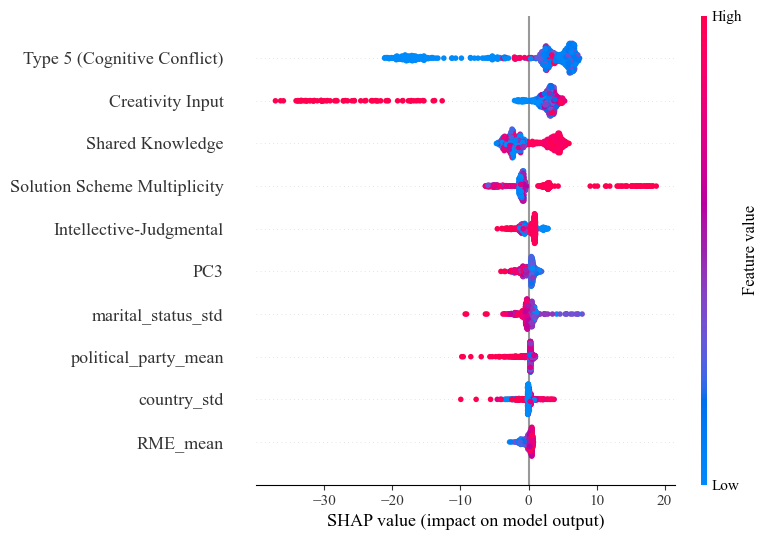

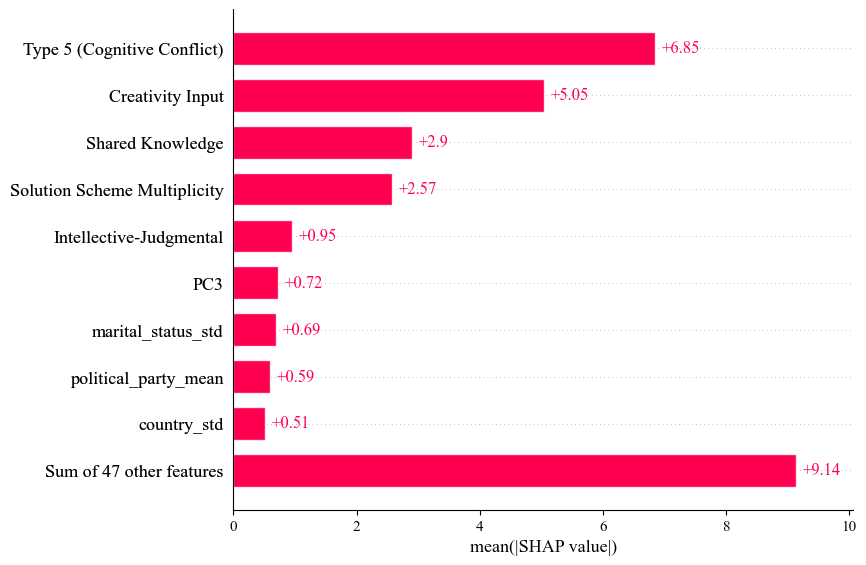

Examining optimal model for roundId_task
Number of datapoints:
771
                         feature  importance_gini  importance_permutation  \
40   Type 5 (Cognitive Conflict)         0.144921                0.587468   
48              Creativity Input         0.149479                0.404585   
42  Solution Scheme Multiplicity         0.085480                0.194045   
46         Conflicting Tradeoffs         0.049411                0.176733   
35            marital_status_std         0.048725                0.065701   
11         political_social_mean         0.019585                0.056326   
53                           PC3         0.036382                0.053011   
8                   IRCS_IV_mean         0.019893                0.050287   
4                   IRCS_GS_mean         0.036745                0.048514   
33           education_level_std         0.034162                0.041885   

    importance_shap  
40         9.204336  
48         6.455637  
42         3.568519

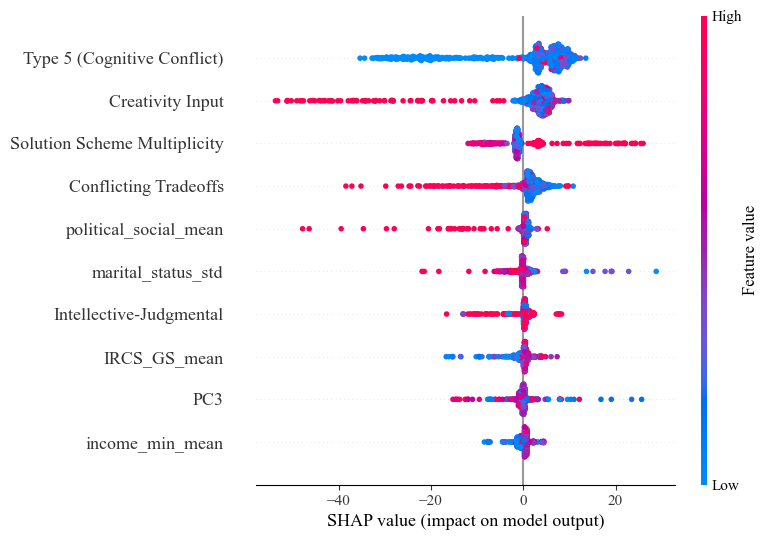

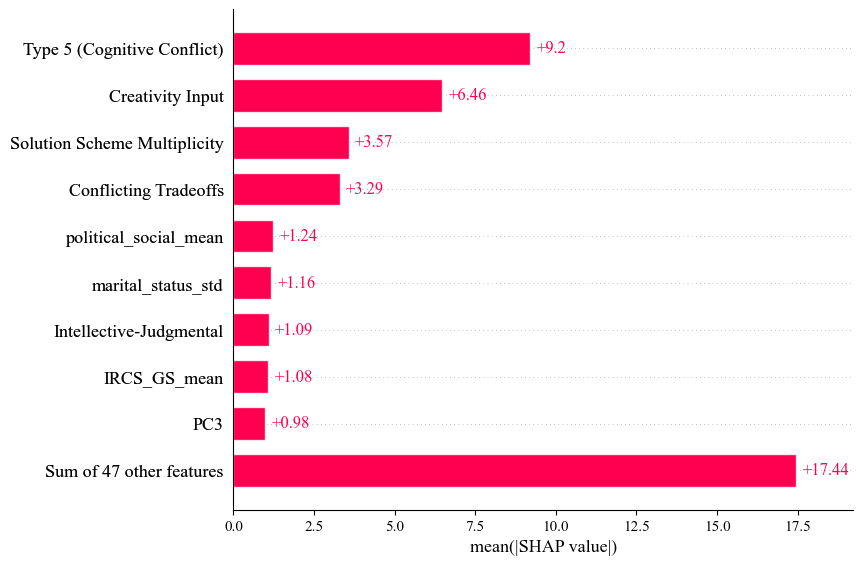

In [ ]:
variable_importances_by_model_agg_type = {}

for model_agg_type in optimal_models.keys():
	print("Examining optimal model for " + model_agg_type)
	
	data = data_for_model_agg_types[model_agg_type]
	HorseRaceOptimizedModel_obj = HorseRaceOptimizedModel_objects[model_agg_type]
	model = optimal_models[model_agg_type]

	# fit the model 
	X = data[HorseRaceOptimizedModel_obj.X.columns]
	y = data[HorseRaceOptimizedModel_obj.y_name]

	print("Number of datapoints:")
	print(X.shape[0])
	
	# Fit the model
	model.fit(X, y)
	
	"""
	The impurity-based feature importances.
	The higher, the more important the feature. 
	The importance of a feature is computed as the (normalized) total reduction of the criterion 
	brought by that feature. It is also known as the Gini importance.

	"""
	gini_importances = model.feature_importances_

	"""
	The permutation feature importance.
	---
	Sklearn documentation:
	Permutation importance for feature evaluation [BRE].
	The estimator is required to be a fitted estimator. 
	X can be the data set used to train the estimator or a hold-out set. 
	The permutation importance of a feature is calculated as follows. 
	First, a baseline metric, defined by scoring, is evaluated on a (potentially different) dataset defined by the X. 
	Next, a feature column from the validation set is permuted and the metric is evaluated again. 
	The permutation importance is defined to be the difference between the baseline metric and 
	metric from permutating the feature column.

	"""
	perm_importance = permutation_importance(model, X, y)

	"""
	Feature importance based on SHAP values
	"""
	explainer = shap.TreeExplainer(model)
	shap_values = explainer.shap_values(X)

	shap_importance = np.mean(np.abs(shap_values), axis = 0)

	# put it all together
	feat_importances = pd.DataFrame({"feature": model.feature_names_in_,
			"importance_gini": gini_importances,
			"importance_permutation": perm_importance.importances_mean,
			"importance_shap": shap_importance})

	feat_importances = feat_importances.sort_values(by = 'importance_permutation', ascending = False)
	
	# save the dataframe
	variable_importances_by_model_agg_type[model_agg_type] = feat_importances

	# show the top 10 features
	print(feat_importances.head(10))
	
	# plot the feature importances using SHAP
	shap.summary_plot(shap_values, X, max_display=10)
	shap.plots.bar(explainer(X), max_display=10)

## Do I need to account for data imbalance issues?

In [ ]:
data_example = HorseRaceOptimizedModel_objects["roundId_task"].HorseRaceData.data
print("Number of unique teams:")
len(data_example["gameId"].drop_duplicates())



Number of unique teams:


213

In [ ]:
unique_players = set()

for player_list in data_example["playerIds"].drop_duplicates().str.split(" ").str[0]:
	for player in player_list.split(","):
		unique_players.add(player)

print(len(unique_players))

948


In [ ]:
data_for_model_agg_types["roundId_task"]["task"].value_counts()

Wolf, goat and cabbage transfer               48
Sudoku                                        48
Writing story                                 48
Guessing the correlation                      48
Recall word lists                             47
Logic Problem                                 46
Room assignment task                          46
Allocating resources to programs              46
Moral Reasoning (Disciplinary Action Case)    46
Typing game                                   44
Advertisement writing                         43
Unscramble words (anagrams)                   42
Recall association                            42
Divergent Association Task                    38
Word construction from a subset of letters    28
Putting food into categories                  28
Random dot motion                             26
Wildcam Gorongosa (Zooniverse)                25
Wildcat Wells                                 23
Whac-A-Mole                                    9
Name: task, dtype: i

In [ ]:
# data_for_model_agg_types["stageId_noncumulative"]["task"].value_counts()

# Quick and Dirty Task Map PCA Plot with the Tasks We Chose

In [6]:
task_map = pd.read_csv('./features/task-mapping/task_map.csv')

# Append PC1 and PC2 to the task map data, using all columns except the first one ("task")
task_map_data = task_map.drop(columns = ["task"])
# get components using PCA function from sklearn
pca = PCA(n_components=2)
pca.fit(task_map_data)
task_map_pca = pca.transform(task_map_data)
task_map["PC1"] = task_map_pca[:, 0]
task_map["PC2"] = task_map_pca[:, 1]

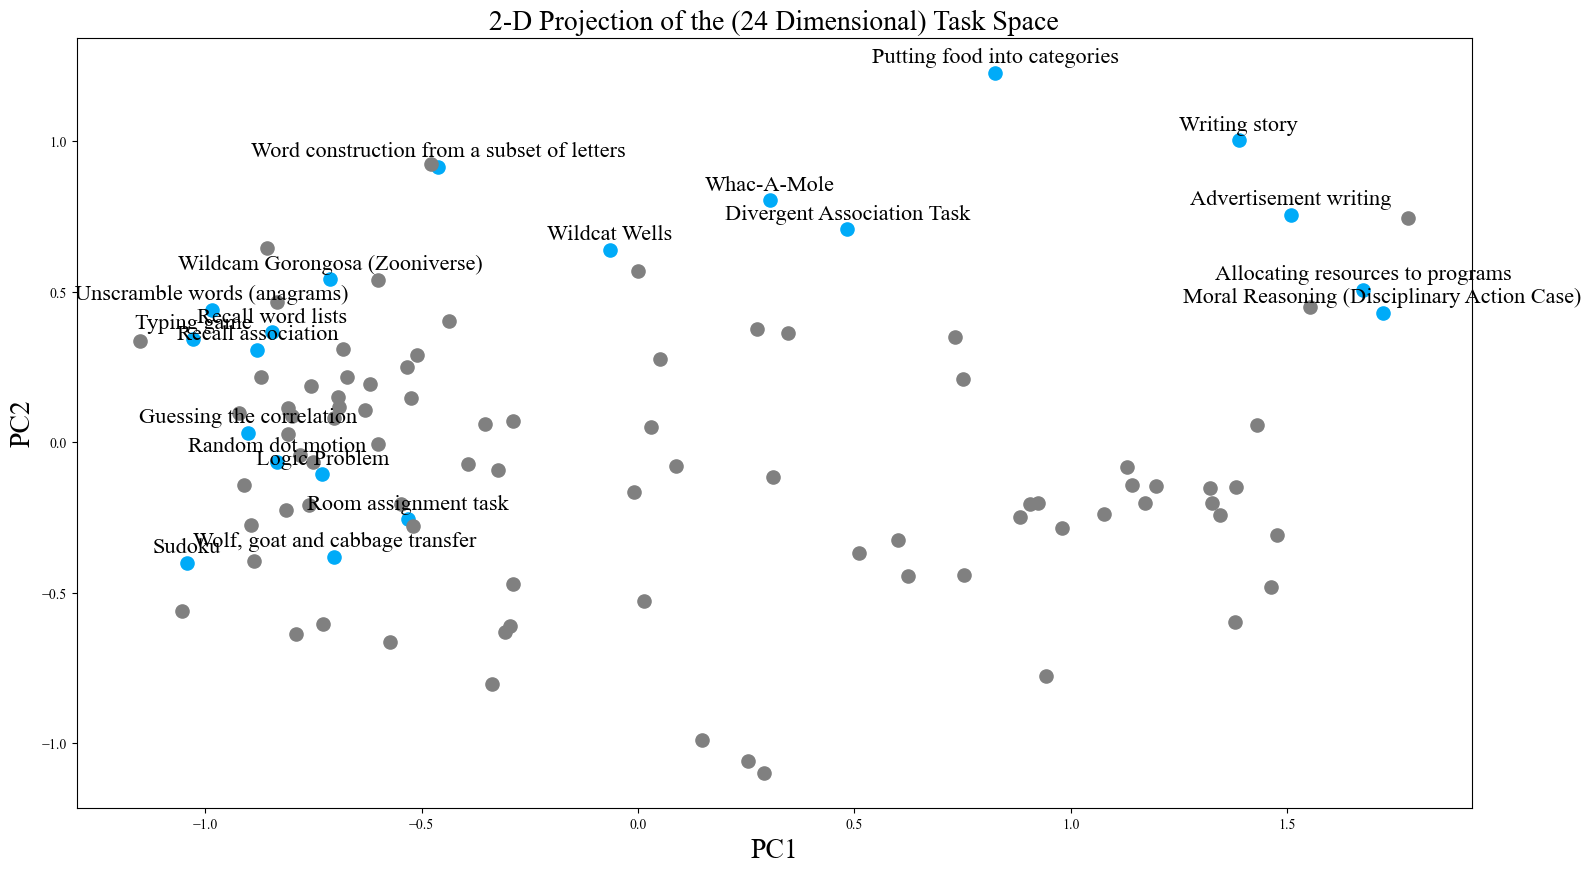

In [36]:
# Plot a 2-dimensional representation of the task map 
SELECTED_TASKS = [
	"Sudoku",
	"Moral Reasoning (Disciplinary Action Case)",
	"Wolf, goat and cabbage transfer",
	"Guessing the correlation",
	"Writing story",
	"Room assignment task",
	"Allocating resources to programs",
	"Divergent Association Task",
	"Word construction from a subset of letters",
	"Whac-A-Mole",
	"Random dot motion",
	"Recall association",
	"Recall word lists",
	"Typing game",
	"Unscramble words (anagrams)",
	"Wildcam Gorongosa (Zooniverse)",
	"Advertisement writing",
	"Putting food into categories",
	"Wildcat Wells",
	"Logic Problem"
]


fig, ax = plt.subplots(figsize=(18, 10))  # Increase the overall plot size
# Define colors
selected_color = '#00ABF8'
default_color = 'grey'

for task in task_map["task"].unique():
    task_row = task_map[task_map["task"] == task]
    color = selected_color if task in SELECTED_TASKS else default_color
    
    ax.scatter(task_row["PC1"], task_row["PC2"], color=color, label=task if task in SELECTED_TASKS else "", s=90)
    
    if task in SELECTED_TASKS:
        # Annotate with task name, centered over the points
        for i in range(len(task_row)):
            ax.annotate(task, (task_row["PC1"].iloc[i], task_row["PC2"].iloc[i]+0.05), 
                        color='black', ha='center', va='center', fontsize=16)

plt.title("2-D Projection of the (24 Dimensional) Task Space", fontsize=20)
plt.xlabel("PC1", fontsize=20)
plt.ylabel("PC2", fontsize=20)

plt.show()

# Recombine Importances into their Categories

Key attributes of an instance of the HorseRaceData class:
- self.task_name: the column containing task names
- self.task_features: the Task Features
- self.task_complexity_features: the Task Complexity Features
- self.composition_features: the Team Composition Features
- self.size_feature: the Team Size Feature
- self.conversation_features: the Team Conversation Features (from TPM)
- self.dvs: the dependent variables

In [11]:
var_importances_by_model_and_feature_type = {}

for model_agg_type in variable_importances_by_model_agg_type.keys():
	variable_importance_df = variable_importances_by_model_agg_type[model_agg_type]

	horseracedata = HorseRaceOptimizedModel_objects[model_agg_type].HorseRaceData
	
	# add a column for the "type" of feature (e.g., Communication, Composition, Size, Task, Task Complexity)
	task_features = horseracedata.task_features.columns
	task_complexity_features = horseracedata.task_complexity_features.columns
	composition_features = horseracedata.composition_features.columns
	size_feature = pd.DataFrame(horseracedata.size_feature).columns
	conversation_features = horseracedata.conversation_features.columns

	feature_types = []
	for feature in variable_importance_df.feature:
		if feature in task_features:
			feature_types.append('Task')
		elif feature in task_complexity_features:
			feature_types.append('Task Complexity')
		elif feature in composition_features:
			feature_types.append('Composition')
		elif feature in size_feature:
			feature_types.append('Size')
		elif feature in conversation_features:
			feature_types.append('Communication')
	
	variable_importance_df['feature_type'] = feature_types
	
	# Now aggregate the feature importances by feature type
	variable_importance_by_feature_type = variable_importance_df.groupby('feature_type').agg({'importance_gini': ['mean', 'max', 'sum'], 'importance_permutation': ['mean', 'max', 'sum'], 'importance_shap': ['mean', 'max', 'sum']}).reset_index()
	# sort by the max permutation importance
	variable_importance_by_feature_type = variable_importance_by_feature_type.sort_values(by = ('importance_permutation', 'max'), ascending = False)

	var_importances_by_model_and_feature_type[model_agg_type] = variable_importance_by_feature_type

In [12]:
for model_agg_type in variable_importances_by_model_agg_type.keys():
	print("Model Aggregation Type: " + model_agg_type)
	print(var_importances_by_model_and_feature_type[model_agg_type].to_string(index = False))

Model Aggregation Type: roundId_cumulative
 feature_type importance_gini                   importance_permutation                   importance_shap                   
                         mean      max      sum                   mean      max      sum            mean      max       sum
         Task        0.041807 0.139367 0.501680               0.069301 0.280900 0.831615        1.677015 6.616558 20.124175
  Composition        0.010743 0.031193 0.408245               0.009062 0.028625 0.344362        0.209605 0.679325  7.964973
Communication        0.017578 0.025042 0.087891               0.015074 0.026415 0.075370        0.341312 0.755333  1.706558
         Size        0.002184 0.002184 0.002184               0.002358 0.002358 0.002358        0.134918 0.134918  0.134918
Model Aggregation Type: roundId_task
 feature_type importance_gini                   importance_permutation                   importance_shap                   
                         mean      max      sum     

In [13]:
var_importances_by_model_and_feature_type_proportions = {}

# calculate the value as a proportion of the whole
for model_agg_type in var_importances_by_model_and_feature_type.keys():
	var_importance_df = var_importances_by_model_and_feature_type[model_agg_type].copy()
	
	for importance_metric in ['importance_gini', 'importance_permutation', 'importance_shap']: 
		for agg_type in ['mean', 'max', 'sum']:
			var_importance_df[(importance_metric, agg_type)] = var_importance_df[(importance_metric, agg_type)] / var_importance_df[(importance_metric, agg_type)].sum()
   
	var_importances_by_model_and_feature_type_proportions[model_agg_type] = var_importance_df

In [14]:
importance_type_to_readable_name = {
	'importance_gini': 'Gini',
	'importance_permutation': 'Permutation',
	'importance_shap': 'SHAP'
}

In [15]:
importance_aggregate_type_to_readable_name = {
	'mean': 'Mean',
	'max': 'Max',
	'sum': 'Sum'
}

In [16]:
def plot_feature_importances_by_feature_type(agg_type, model_agg_type):
	var_importance_df = var_importances_by_model_and_feature_type_proportions[model_agg_type]
	
	# Filter to get the data for the model aggregation type and stack the data
	var_importance_df = var_importance_df.set_index('feature_type')
	var_importance_df = var_importance_df.stack().reset_index()
	var_importance_df = var_importance_df[var_importance_df['level_1'] == agg_type].drop(columns='level_1', axis=1)
	
	# Melt the DataFrame to pivot it
	var_importance_df = var_importance_df.melt(id_vars='feature_type', var_name='importance_metric', value_name='value')
	
	# Filter to get the data for the importance metrics ('importance_gini', 'importance_permutation', 'importance_shap')
	var_importance_df = var_importance_df[var_importance_df['importance_metric'].isin(['importance_gini', 'importance_permutation', 'importance_shap'])]
	
	# Normalize the values within each importance metric and feature type
	var_importance_df['total_value'] = var_importance_df.groupby('importance_metric')['value'].transform('sum')
	var_importance_df['normalized_value'] = var_importance_df['value'] / var_importance_df['total_value']
	
	# Pivot the DataFrame to have 'importance_metric' as the index and 'feature_type' as columns
	var_importance_df = var_importance_df.pivot(index='importance_metric', columns='feature_type', values='normalized_value').reset_index()
	print(var_importance_df.to_string())

	# Plot the data
	fig, ax = plt.subplots(figsize=(10, 6))
	var_importance_df.plot(kind='bar', x='importance_metric', stacked=True, ax=ax)
	
	# Update x-axis labels using the dictionary
	ax.set_xticklabels([importance_type_to_readable_name.get(x, x) for x in var_importance_df['importance_metric']], rotation=0)
	plt.xticks(fontsize=18)
	plt.yticks(fontsize=16)

	ax.set_ylabel('Proportion of Feature Importance', fontsize = 20)
	ax.set_xlabel('Importance Metric', fontsize = 20)
	ax.set_title(f'Feature Importance by Feature Type (Aggregating Importance by {importance_aggregate_type_to_readable_name[agg_type]})')
	ax.legend(title='Feature Category', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize = 14, title_fontsize=18)
	

	plt.tight_layout()
	plt.show()

Model Aggregation Type: roundId_cumulative
feature_type       importance_metric  Communication  Composition      Size      Task
0                    importance_gini       0.243089     0.148569  0.030198  0.578144
1             importance_permutation       0.157356     0.094599  0.024618  0.723427
2                    importance_shap       0.144449     0.088708  0.057100  0.709743


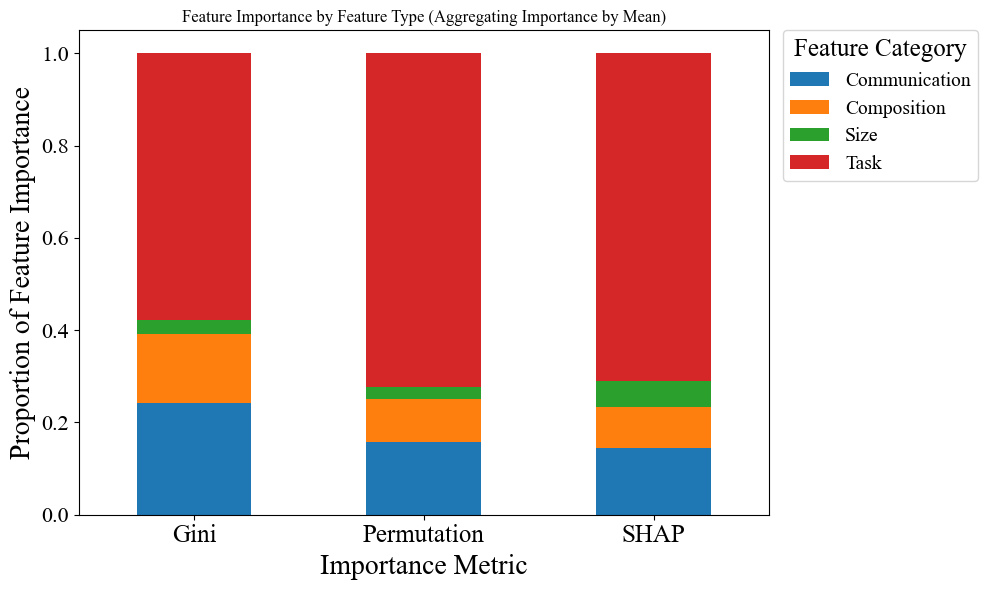

Model Aggregation Type: roundId_task
feature_type       importance_metric  Communication  Composition      Size      Task
0                    importance_gini       0.169218     0.151758  0.101697  0.577327
1             importance_permutation       0.162450     0.103243  0.059729  0.674578
2                    importance_shap       0.166400     0.131169  0.112235  0.590196


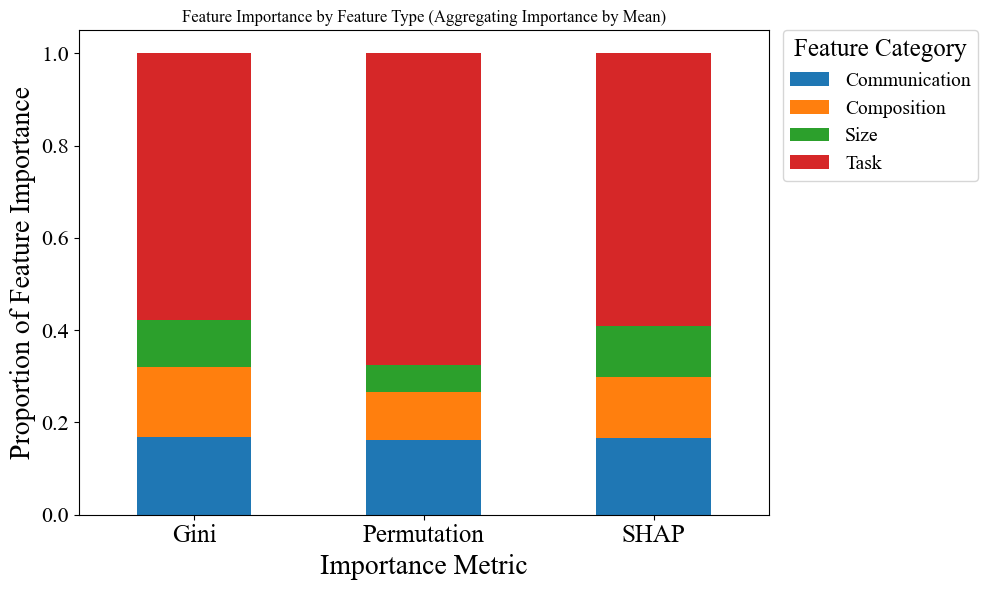

In [17]:
for model_agg_type in var_importances_by_model_and_feature_type_proportions.keys():
	print("Model Aggregation Type: " + model_agg_type)
	plot_feature_importances_by_feature_type('mean', model_agg_type)